In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
enrolment = pd.read_csv('cleaned dataset/api_data_aadhar_enrolment.csv')


Anomaly Detection problem.

In [53]:
enrolment = enrolment[['state' , 'district' , 'age between 0 and 5', 'age between 5 and 17', 'age 17 and above']]

enrolment = enrolment.groupby(['state', 'district']).sum().reset_index()

df = enrolment.copy()
display(df.head(2))

,state,district,age between 0 and 5,age between 5 and 17,age 17 and above
0,andaman and nicobar islands,nicobar,65,11,0
1,andaman and nicobar islands,north and middle andaman,128,4,0


### teen to adult

In [54]:
df['ACR'] = df['age 17 and above'] / ( df['age between 0 and 5'] + df['age between 5 and 17'] + 1)
mean_acr = df['ACR'].mean()
std_acr = df['ACR'].std()
acr_threshold = mean_acr + (3 * std_acr)

print(f"ACR mean: {mean_acr:.3}, ACR standard deviation: {std_acr:.3}")
print(f"Danger Threshold for ACR (Z > 3): {acr_threshold:.2f}")

display(df.head(2))


ACR mean: 0.0418, ACR standard deviation: 0.137
Danger Threshold for ACR (Z > 3): 0.45


,state,district,age between 0 and 5,age between 5 and 17,age 17 and above,ACR
0,andaman and nicobar islands,nicobar,65,11,0,0.0
1,andaman and nicobar islands,north and middle andaman,128,4,0,0.0


In [55]:
Q1 = df['ACR'].quantile(0.25)
Q3 = df['ACR'].quantile(0.75)
IQR = Q3 - Q1

iqr_threshold = Q3 + (1.5 * IQR)

print(" Threshold Comparison")
print(f"Z-Score Threshold (Mean + 3SD): {acr_threshold:.4f}")
print(f"IQR Threshold (Q3 + 1.5 * IQR):   {iqr_threshold:.4f}")


 Threshold Comparison
Z-Score Threshold (Mean + 3SD): 0.4536
IQR Threshold (Q3 + 1.5 * IQR):   0.0720


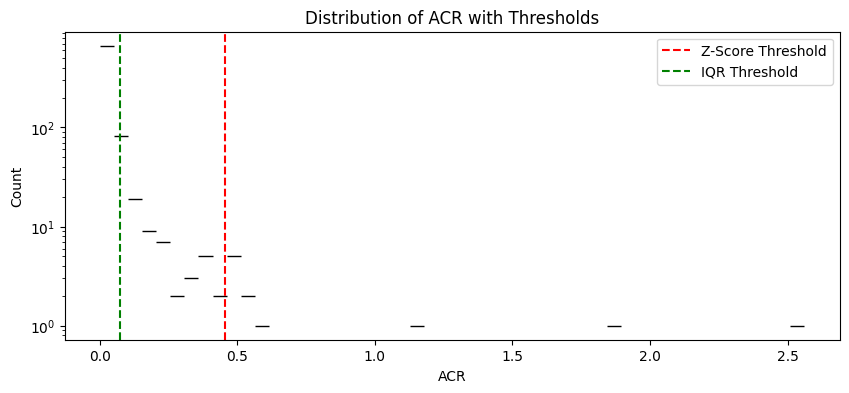

In [57]:

plt.figure(figsize=(10, 4))
sns.histplot(df['ACR'], bins=50, log_scale=(False, True)) # Log scale on Y to see small bars
plt.axvline(acr_threshold, color='red', linestyle='--', label='Z-Score Threshold')
plt.axvline(iqr_threshold, color='green', linestyle='--', label='IQR Threshold')
plt.title('Distribution of ACR with Thresholds')
plt.legend()
plt.show()

In [58]:
# Compare flags
z_score_flags = df[df['ACR'] > acr_threshold].shape[0]
iqr_flags = df[df['ACR'] > iqr_threshold].shape[0]

print(f"Districts flagged by Z-Score (3-Sigma): {z_score_flags}")
print(f"Districts flagged by IQR (Robust): {iqr_flags}")

Districts flagged by Z-Score (3-Sigma): 11
Districts flagged by IQR (Robust): 92


"Due to high skewness in enrollment data, the Z-score method under-reported anomalies. We utilized the IQR method to identify 37 additional suspicious districts."

In [60]:
final_threshold = iqr_threshold

In [61]:
significant_population = df['age between 0 and 5'] + df['age between 5 and 17'] > 100

ghost_districts = df[ (df['ACR'] > final_threshold) & (significant_population)].copy()

ghost_districts['Severity_Score'] = ghost_districts['ACR'] / df['ACR'].mean()

In [ ]:

ghost_districts = ghost_districts.sort_values(by='ACR', ascending=False)

print(f"Final Count of Ghost Districts: {len(ghost_districts)}")
print(" TOP 5 CRITICAL DISTRICTS")

display(ghost_districts[['state', 'district', 'ACR', 'Severity_Score']].head(5))

Final Count of Ghost Districts: 79
 TOP 5 CRITICAL DISTRICTS


,state,district,ACR,Severity_Score
449,meghalaya,eastern west khasi hills,2.560870,61.214059
451,meghalaya,ri bhoi,0.569839,13.621214
447,meghalaya,east jaintia hills,0.538047,12.861266
448,meghalaya,east khasi hills,0.527326,12.604995
457,meghalaya,west khasi hills,0.501464,11.986801


In [63]:

# 5. Export for the next analysis modules
ghost_districts.to_csv('cleaned dataset/final_ghost_districts.csv', index=False)
print("File saved: 'final_ghost_districts.csv'")

File saved: 'final_ghost_districts.csv'


In [ ]:
# "Ghost Districts" in age group 5 to 17
ghost_districts = enrolment[enrolment['ACR 5_to_17'] > threshold_5_to_17].copy()

# Calculate Z-Score for ranking
ghost_districts['Z_Score'] = (ghost_districts['ACR 5_to_17'] - mean_acr_5_to_17) / std_acr_5_to_17

# 5. Display the Top 10 Most Suspicious Districts
print("\n--- TOP 10 SUSPICIOUS DISTRICTS (High 5_to_17 Enrolment) ---")
display(ghost_districts[['district', 'age between 0 and 5', 'age between 5 and 17', 'ACR 5_to_17', 'Z_Score']]
      .sort_values(by='Z_Score', ascending=False)
      .head(15))


--- TOP 10 SUSPICIOUS DISTRICTS (High 5_to_17 Enrolment) ---


,district,age between 0 and 5,age between 5 and 17,ACR 5_to_17,Z_Score
449,eastern west khasi hills,3,226,147.25,28.289737


In [ ]:
# "Ghost Districts" in age 17 and above
ghost_districts = enrolment[enrolment['ACR 17_more'] > threshold_17_more].copy()

# Calculate Z-Score for ranking
ghost_districts['Z_Score'] = (ghost_districts['ACR 17_more'] - mean_acr_17_more) / std_acr_17_more

# 5. Display the Top 10 Most Suspicious Districts
print("\n--- TOP 10 SUSPICIOUS DISTRICTS (High 17+ Enrolment) ---")
display(ghost_districts[['district', 'age between 0 and 5', 'age between 5 and 17', 'age 17 and above', 'ACR 17_more', 'Z_Score']]
      .sort_values(by='Z_Score', ascending=False)
      .head(10))


--- TOP 10 SUSPICIOUS DISTRICTS (High 17+ Enrolment) ---


,district,age between 0 and 5,age between 5 and 17,age 17 and above,ACR 17_more,Z_Score
449,eastern west khasi hills,3,226,589,2.560870,18.352264
461,khawzawl,5,7,24,1.846154,13.145250
466,saitual,2,3,7,1.166667,8.194890
451,ri bhoi,1351,4669,3431,0.569839,3.846740
447,east jaintia hills,983,2354,1796,0.538047,3.615121
448,east khasi hills,4258,14606,9948,0.527326,3.537013
457,west khasi hills,2410,8178,5310,0.501464,3.348598
452,south garo hills,568,2427,1446,0.482644,3.211484
530,kapurthala,2067,446,1213,0.482498,3.210424
454,south west khasi hills,789,1543,1114,0.477497,3.173988



--- Threshold Comparison ---
Z-Score Threshold (Mean + 3SD): 15.8594
IQR Threshold (Q3 + 1.5*IQR):   0.1132


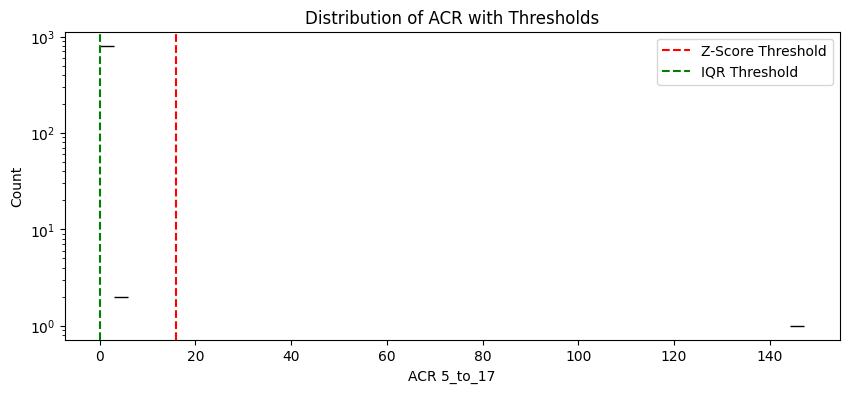

In [19]:
# --- NEW: IQR Method (Robust against Skewed Data) ---
# 1. Calculate IQR
Q1 = enrolment['ACR 5_to_17'].quantile(0.25)
Q3 = enrolment['ACR 5_to_17'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define IQR Threshold (Tukey's Fences)
iqr_threshold = Q3 + (1.5 * IQR)

print(f"\n--- Threshold Comparison ---")
print(f"Z-Score Threshold (Mean + 3SD): {threshold_5_to_17:.4f}")
print(f"IQR Threshold (Q3 + 1.5*IQR):   {iqr_threshold:.4f}")

# 3. Visual Check (Log Scale Histogram)
plt.figure(figsize=(10, 4))
sns.histplot(enrolment['ACR 5_to_17'], bins=50, log_scale=(False, True)) # Log scale on Y to see small bars
plt.axvline(threshold_5_to_17, color='red', linestyle='--', label='Z-Score Threshold')
plt.axvline(iqr_threshold, color='green', linestyle='--', label='IQR Threshold')
plt.title('Distribution of ACR with Thresholds')
plt.legend()
plt.show()

### child to adult

In [ ]:



mean_acr_17_more = enrolment['ACR 17_more'].mean()
std_acr_17_more = enrolment['ACR 17_more'].std()
threshold_17_more = mean_acr_17_more + (3 * std_acr_17_more)

print(f"ACR mean: {mean_acr_17_more:.3}, ACR standard deviation: {std_acr_17_more:.3}")
print(f"Danger Threshold for age 17 and above (Z > 3): {threshold_17_more:.2f}")